In [2]:
import numpy as np

def stationary_distribution(P):
    """
    Find one stationary distribution pi satisfying

        pi @ P = pi
        sum(pi) = 1

    P is assumed row-stochastic.
    """
    P = np.asarray(P, dtype=float)  
    "Converts P into a NumPy array of type float."
    n = P.shape[0]  
    "Gets the number of states (rows) in the transition matrix P."

    A = np.vstack([
        P.T - np.eye(n),
        np.ones(n)
    ])
    "vstac ks the transposed transition matrix minus the identity matrix with a"
    "row of ones to form the augmented matrix A (eye creates the nxn identity matrix)."

    b = np.r_[np.zeros(n), 1.0]
    "Constructs the right-hand side vector b, which consists of n zeros followed by a 1.0."

    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    "solves the least squares problem A @ pi = b to find the stationary distribution pi."
    "pi, *_ = means put the first element of the returned tuple into pi and ignore the rest."

    pi[np.abs(pi) < 1e-14] = 0.0
    "Cleans up the solution by setting very small values (less than 1e-14) to zero to avoid numerical issues."
    
    return pi / pi.sum()
    "return the normalized stationary distribution by dividing pi by its sum to ensure it sums to 1."
    
    
def simulate_markov(P, T, s0 = 0, seed=None):
    """
    This defines a function that simulates a Markov chain.
    """
    rng = np.random.default_rng(seed)
    "Creates a random number generator instance with an optional seed for reproducibility."
    
    P = np.asarray(P, dtype=float)
    n = P.shape[0]
    
    states = np.empty(T, dtype=int)
    "Creates an array to hold the states of the Markov chain, initialized to empty with integer type."
    states[0] = s0
    
    for t in range(T-1):
        states[t+1] = rng.choice(
            n,
            p = P[states[t]]
        )
        "it randomly selects the next state based on the current state and the transition probabilities defined in P."
        "results are saved in the states array."
        
    return states
"the output is the realized path of the Markov chain over T time steps, starting from the initial state s0."

def k_step_distribution(P, current_state, k):
    """
    This function computes the distribution of states after k steps in a Markov chain.
    """
    Pk = np.linalg.matrix_power(P, k)
    "Calculates the k-th power of the transition matrix P, which gives the transition probabilities after k steps."
    return Pk[current_state]

def forecast_function(P, values, current_states, k):
    """
    This function gives a forecast of the expected future value of a variable when that
    variable depends on the state of a Markov chain.
    P = transition matrix of the Markov chain,
    values = numerical value of y corresponding to each state of the Markov chain,
    current_states = the current state of the Markov chain,
    k = number of steps ahead to forecast.
    """
    Pk = np.linalg.matrix_power(P, k)
    "Calculates the k-th power of the transition matrix P, which gives the transition probabilities after k steps."
    return round((Pk @ values)[current_states], 2)

def discounted_markov_value(P, payoff, beta):
    """
    This function computes the discounted value of a Markov chain with a given payoff and discount factor.
    P = transition matrix of the Markov chain,
    payoff = numerical value of y corresponding to each state of the Markov chain,
    beta = discount factor.
    """
    n = P.shape[0]
    
    return np.linalg.solve(
        np.eye(n) - beta * P,
        payoff
    )
    """
    np.linalg.solve solves the linear system (I - beta * P) * V = payoff for V, where I is the identity matrix.
    """

def markov_loglik(path, P, pi0):
    """
    This function computes the log-likelihood of a given path in a Markov chain.
    path = sequence of states observed,
    P = transition matrix of the Markov chain,
    pi0 = initial distribution over states.
    """
    path = np.asarray(path, dtype = int)
    "Converts the input path into a NumPy array of integers."
    
    probs = [pi0[path[0]]]
    
    for t in range(len(path)-1):
        probs.append(
            P[path[t], path[t+1]]
        )
    probs = np.array(probs)
    "Calculates the probabilities of the observed transitions in the path based on the transition matrix P"
    
    if np.any(probs == 0):
        return -np.inf
    "If any of the probabilities are zero, the log-likelihood is negative infinity."
    
    return np.log(probs).sum()
    """
    Returns the sum of the logarithms of the transition probabilities, which is the log-likelihood of the observed path.
    """
    
def estimate_transition_matrix(path, n_states):
    """
    Unrestricted maximum likelihood estimation of the transition matrix of a Markov chain.
    """
    counts = np.zeros((n_states, n_states), dtype=int)
    "Initializes a counts matrix to keep track of transitions between states."
        
    for i, j in zip(path[:-1], path[1:]):
         counts[i, j] += 1
    "Iterates through the path and counts the transitions from state i to state j."
        
    row_totals = counts.sum(axis = 1, keepdims=True)
    "Calculates the total number of transitions from each state."
        
    return np.divide(
        counts,
        row_totals,
        out = np.zeros_like(counts, dtype=float),
        where = row_totals != 0
    )
        
    

# Macroeconomic application: recession, expansion, and fiscal revenues

Imagine you work in a macroeconomic forecasting team. The economy is currently in recession, and you need to answer several connected questions:

- How likely is a recovery next quarter or next year?
- What growth and unemployment rates should we expect?
- How much time does the economy spend in recession over the long run?
- How do business-cycle conditions affect expected future fiscal revenues?
- How can we evaluate and estimate the transition probabilities from a recorded history?

We answer these questions using **the same seven general functions defined above**. Each function studies a different aspect of one finite-state Markov model.

This is a realistic *type* of macroeconomic application with **illustrative parameters**. The probabilities and economic values below are chosen for teaching; they are not estimates for a particular country. We observe the regime directly in this example. Inferring unobserved regimes from GDP data would require additional tools.

## Model setup: two quarterly business-cycle regimes

Let $s_t$ be the state of the economy in quarter $t$:

| State code | Regime | Annualized quarterly real GDP growth | Unemployment rate | Quarterly fiscal revenue |
|---|---|---:|---:|---:|
| 0 | Recession | −2% | 9% | 80 billion currency units |
| 1 | Expansion | +3% | 5% | 100 billion currency units |

These quantities are **functions of the regime**. The model simplifies reality by assigning one value to each regime. Growth rates use percent units, so `-2.0` means −2%, and unemployment rates use percent units as well.

The transition matrix is

$$
P=\begin{bmatrix}0.75&0.25\\0.08&0.92\end{bmatrix},
\qquad P_{ij}=\Pr(s_{t+1}=j\mid s_t=i).
$$

Rows describe today's regime; columns describe next quarter's regime:

| Today's regime | Recession next quarter | Expansion next quarter |
|---|---:|---:|
| Recession | 75% | 25% |
| Expansion | 8% | 92% |

Thus, a recession persists into the next quarter with probability 0.75, while an expansion persists with probability 0.92. Conditional on today's regime, earlier regimes do not change these probabilities: this is the **Markov property**. We also assume the transition probabilities remain constant through time.


In [3]:
import matplotlib.pyplot as plt

P = np.array([[0.75, 0.25],
              [0.08, 0.92]])
regime_names = np.array(["Recession", "Expansion"])
growth = np.array([-2.0, 3.0])
unemployment = np.array([9.0, 5.0])
revenue = np.array([80.0, 100.0])
current_state = 0

# Check the economic interpretation of each row as a probability distribution.
assert np.all(P >= 0)
assert np.allclose(P.sum(axis=1), 1)


## 1. `stationary_distribution`: how often is the economy in recession?

The short-run outlook depends on today's regime. A different question is the fraction of time spent in each regime over a sufficiently long history.

Your function finds a row vector $\pi$ satisfying

$$
\pi P=\pi,\qquad \pi_0+\pi_1=1.
$$

If the initial distribution is $\pi$, it remains $\pi$ every quarter. Here, both regimes communicate and each has a positive probability of remaining in place. Consequently, the stationary distribution is unique, and distributions starting from either regime converge to it.


In [3]:
pi = stationary_distribution(P)
for name, probability in zip(regime_names, pi):
    print(f"Long-run share in {name.lower()}: {probability:.2%}")
print(f"Long-run mean annualized growth: {pi @ growth:.3f}%")
print(f"Long-run mean unemployment: {pi @ unemployment:.3f}%")
print(f"Long-run mean quarterly revenue: {pi @ revenue:.3f} billion")
assert np.allclose(pi @ P, pi)


Long-run share in recession: 24.24%
Long-run share in expansion: 75.76%
Long-run mean annualized growth: 1.788%
Long-run mean unemployment: 5.970%
Long-run mean quarterly revenue: 95.152 billion


We obtain

$$
\pi=\begin{bmatrix}0.242424&0.757576\end{bmatrix}.
$$

Under this calibration, the economy spends about **24.24% of quarters in recession** and **75.76% in expansion** in the long run. These are time shares, not a prediction that the next 100 quarters must contain exactly 24 recessions.

The equilibrium probability flows balance:

$$
\pi_0\times0.25=\pi_1\times0.08.
$$

The average annualized quarterly growth rate is

$$
E_\pi[g(s_t)]=\pi g\approx1.788\%,
$$

and average unemployment is approximately 5.970%. The growth average is an average of the regime-specific rates; it does not compound those rates into a long-run GDP level.

Persistence also explains why expansion occupies more time. A spell starting when a regime is entered has geometric duration with mean

$$
E[D_i]=\frac{1}{1-P_{ii}}.
$$

Expected recession duration is $1/0.25=4$ quarters; expected expansion duration is $1/0.08=12.5$ quarters. A four-quarter expected duration does **not** mean every recession ends after four quarters.


In [4]:
durations = 1 / (1 - np.diag(P))
for name, duration in zip(regime_names, durations):
    print(f"Expected {name.lower()} spell: {duration:.2f} quarters")


Expected recession spell: 4.00 quarters
Expected expansion spell: 12.50 quarters


## 2. `simulate_markov`: what could a business-cycle history look like?

The transition matrix describes probabilities. Simulation produces one particular sequence of regimes consistent with those probabilities.

Starting in recession, generate 160 quarters, equivalent to 40 years. Your implementation returns **160 states including the initial state**, hence 159 transitions.


Simulated regime shares: [0.25 0.75]
Stationary regime shares: [0.2424 0.7576]


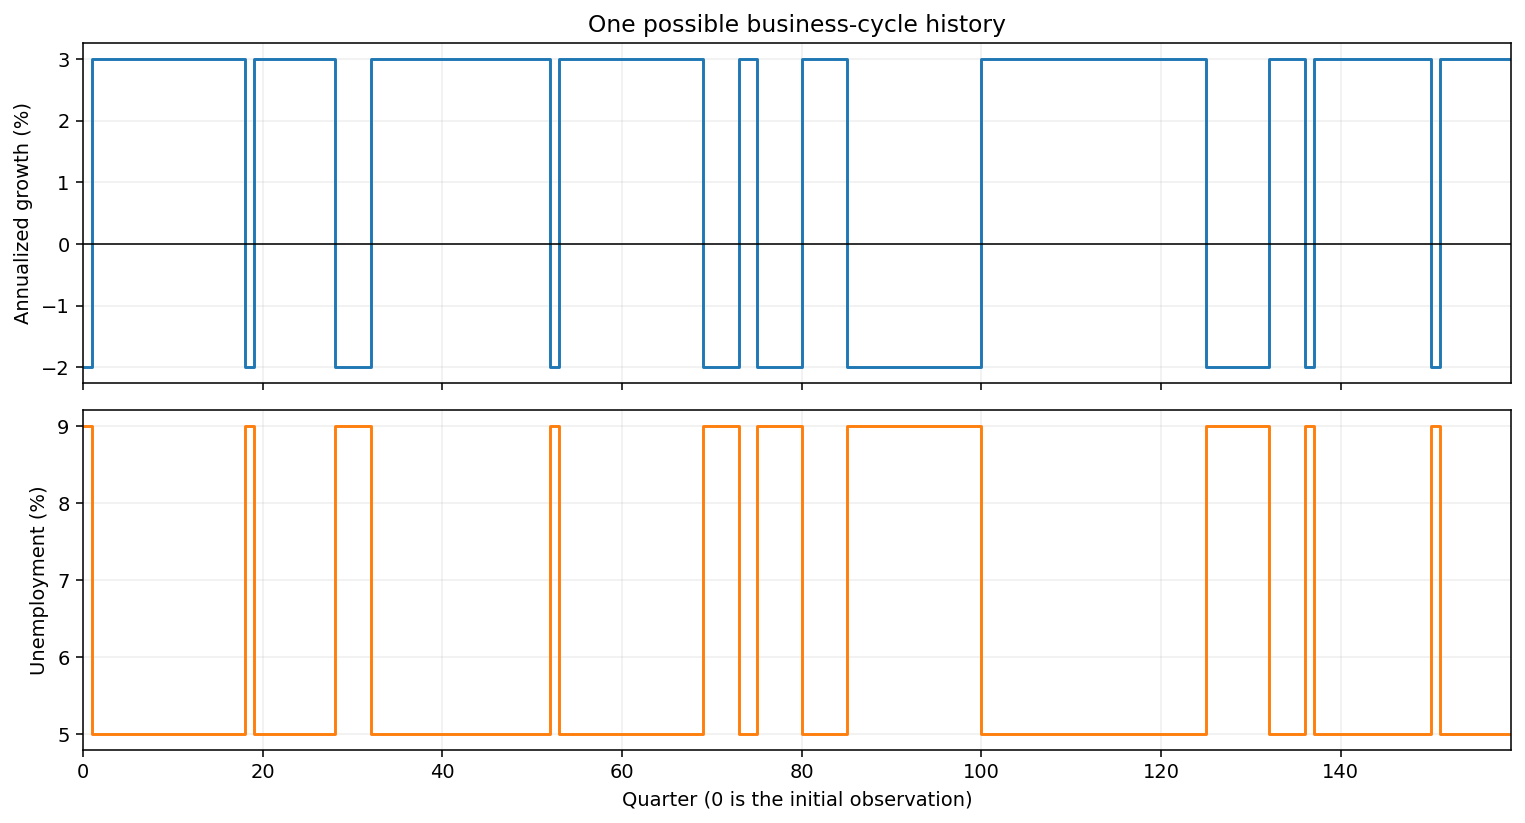

In [5]:
states = simulate_markov(P, T=160, s0=current_state, seed=42)
quarters = np.arange(len(states))
simulated_growth = growth[states]
simulated_unemployment = unemployment[states]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].step(quarters, simulated_growth, where="post", color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Annualized growth (%)")
axes[0].set_title("One possible business-cycle history")
axes[1].step(quarters, simulated_unemployment, where="post", color="tab:orange")
axes[1].set_ylabel("Unemployment (%)")
axes[1].set_xlabel("Quarter (0 is the initial observation)")
for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0, len(states) - 1)
fig.tight_layout()
plt.show()

shares = np.bincount(states, minlength=2) / len(states)
print("Simulated regime shares:", np.round(shares, 4))
print("Stationary regime shares:", np.round(pi, 4))


Periods of negative growth and high unemployment occur together because both variables depend on the same recession regime. Similarly, expansions produce positive growth and lower unemployment. The flat segments reflect our two-value simplification; actual GDP growth and unemployment also vary within regimes.

The history contains clusters of recessions and expansions because the diagonal entries of $P$ are high. A different random seed produces a different history under the same economic model. The simulated shares need not equal $\pi$, especially over short samples and with a specified initial regime.

This is **one possible future**, rather than the expected future path.


## 3. `k_step_distribution`: what is the probability of recovery?

Suppose the economy is in recession today. Your function computes

$$
\Pr(s_{t+k}=j\mid s_t=0)=(P^k)_{0j}.
$$

Matrix powers account for all possible intervening regime sequences. For example,

$$
(P^2)_{01}=0.75\times0.25+0.25\times0.92=0.4175.
$$

The economy can be in expansion two quarters ahead either by remaining in recession first and then recovering, or by recovering immediately and remaining in expansion.


Horizon | Recession probability | Expansion probability
      0 |               100.00% |                 0.00%
      1 |                75.00% |                25.00%
      2 |                58.25% |                41.75%
      4 |                39.51% |                60.49%
      8 |                27.32% |                72.68%
     20 |                24.27% |                75.73%


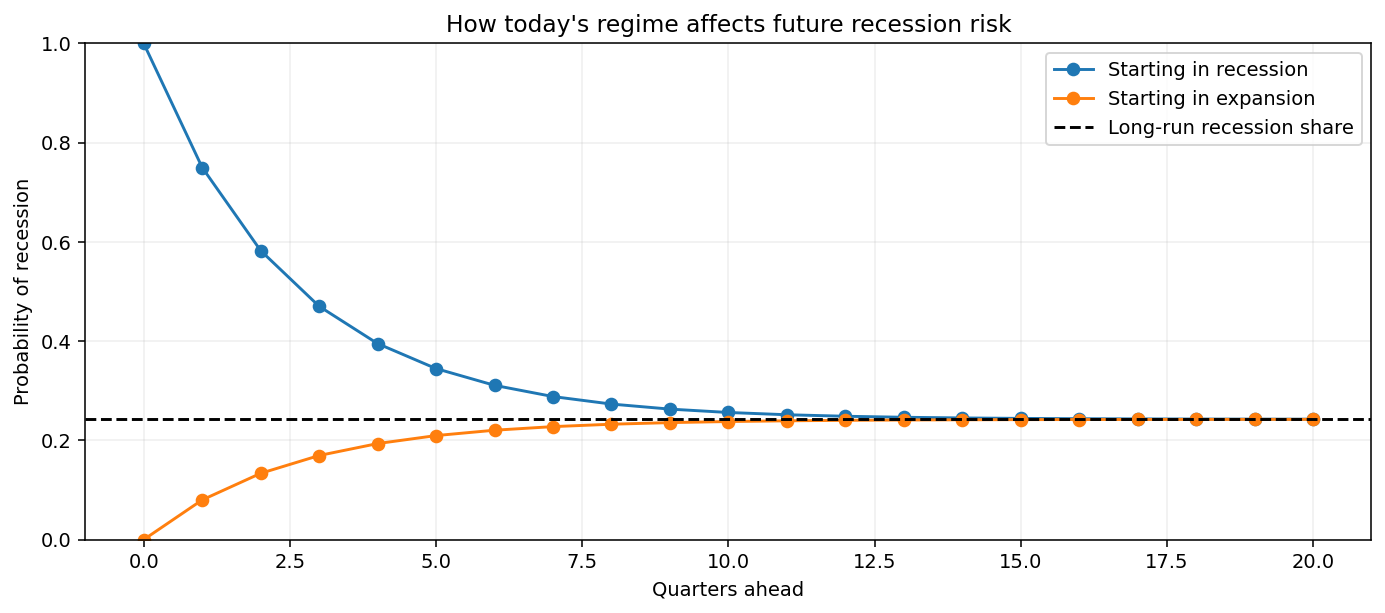

In [6]:
print("Horizon | Recession probability | Expansion probability")
for k in [0, 1, 2, 4, 8, 20]:
    probabilities = k_step_distribution(P, current_state, k)
    print(f"{k:7d} | {probabilities[0]:21.2%} | {probabilities[1]:21.2%}")

horizons = np.arange(21)
recession_probabilities = np.array([
    [k_step_distribution(P, initial, int(k))[0] for k in horizons]
    for initial in [0, 1]
])
fig, ax = plt.subplots(figsize=(10, 4.5))
for initial in [0, 1]:
    ax.plot(horizons, recession_probabilities[initial], marker="o",
            label=f"Starting in {regime_names[initial].lower()}")
ax.axhline(pi[0], color="black", linestyle="--", label="Long-run recession share")
ax.set(xlabel="Quarters ahead", ylabel="Probability of recession",
       title="How today's regime affects future recession risk", ylim=(0, 1))
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


Starting in recession, the probability of being in expansion is 25% next quarter, approximately **60.49% four quarters ahead**, and **72.68% eight quarters ahead**. At long horizons, the recession probability approaches 24.24%, regardless of today's regime.

For this two-state matrix, the second eigenvalue is $0.75+0.92-1=0.67$. It controls how quickly the effect of today's regime disappears:

$$
\Pr(s_{t+k}=0\mid s_t=i)=\pi_0+0.67^k\big(\mathbf{1}\{i=0\}-\pi_0\big).
$$

**Being in expansion at horizon $k$ is different from having recovered at least once by then.** The economy might recover and enter another recession before quarter $t+k$.

The probability that the current recession has ended at least once within four transitions is instead

$$
1-P_{00}^4=1-0.75^4\approx68.36\%.
$$

Your `k_step_distribution` answers the endpoint question, not the first-recovery question.


## 4. `forecast_function`: what growth and unemployment should we expect?

A probability distribution over regimes becomes an economic forecast when we attach a value to each regime.

For a vector $f=[f(0),f(1)]'$, your function computes

$$
E[f(s_{t+k})\mid s_t=i]=(P^k f)_i.
$$

The argument is named `current_states` in your implementation, but here it receives **one integer state code**, `0` or `1`.


 1 quarters ahead: expected growth -0.75%, expected unemployment 8.00%
 4 quarters ahead: expected growth 1.02%, expected unemployment 6.58%
 8 quarters ahead: expected growth 1.63%, expected unemployment 6.09%
20 quarters ahead: expected growth 1.79%, expected unemployment 5.97%


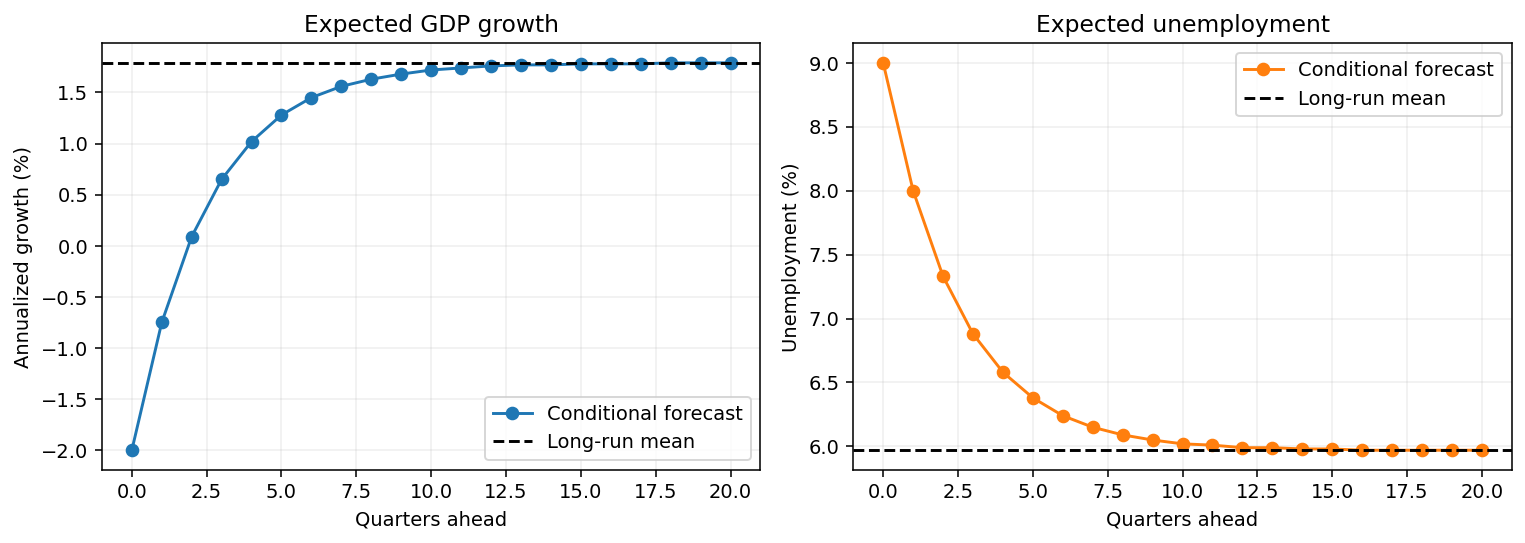

In [7]:
growth_forecast = np.array([
    forecast_function(P, growth, current_states=current_state, k=int(k))
    for k in horizons
])
unemployment_forecast = np.array([
    forecast_function(P, unemployment, current_states=current_state, k=int(k))
    for k in horizons
])
for k in [1, 4, 8, 20]:
    print(f"{k:2d} quarters ahead: expected growth {growth_forecast[k]:.2f}%, "
          f"expected unemployment {unemployment_forecast[k]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(horizons, growth_forecast, marker="o", label="Conditional forecast")
axes[0].axhline(pi @ growth, linestyle="--", color="black", label="Long-run mean")
axes[0].set(xlabel="Quarters ahead", ylabel="Annualized growth (%)", title="Expected GDP growth")
axes[1].plot(horizons, unemployment_forecast, marker="o", color="tab:orange",
             label="Conditional forecast")
axes[1].axhline(pi @ unemployment, linestyle="--", color="black", label="Long-run mean")
axes[1].set(xlabel="Quarters ahead", ylabel="Unemployment (%)", title="Expected unemployment")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


Next quarter's expected growth is

$$
0.75(-2)+0.25(3)=-0.75\%.
$$

Four quarters ahead, it is approximately

$$
0.395084(-2)+0.604916(3)=1.024579\%,
$$

while expected unemployment is approximately 6.580337%. Your function returns these as **1.02** and **6.58** because it rounds to two decimal places.

Expected growth can be positive even when recession risk remains substantial. It averages two possible outcomes; the economy does not acquire a third regime with growth of 1.02%. In our simplified model, realized growth four quarters ahead is still either −2% or +3%.

The forecasts converge to their stationary averages, rather than to zero. This differs from a stable linear model expressed in deviations from equilibrium.

**Implementation note:** rounding inside a general function loses precision. These examples preserve your current definition. For later numerical work, consider returning the unrounded value and rounding only when displaying it.


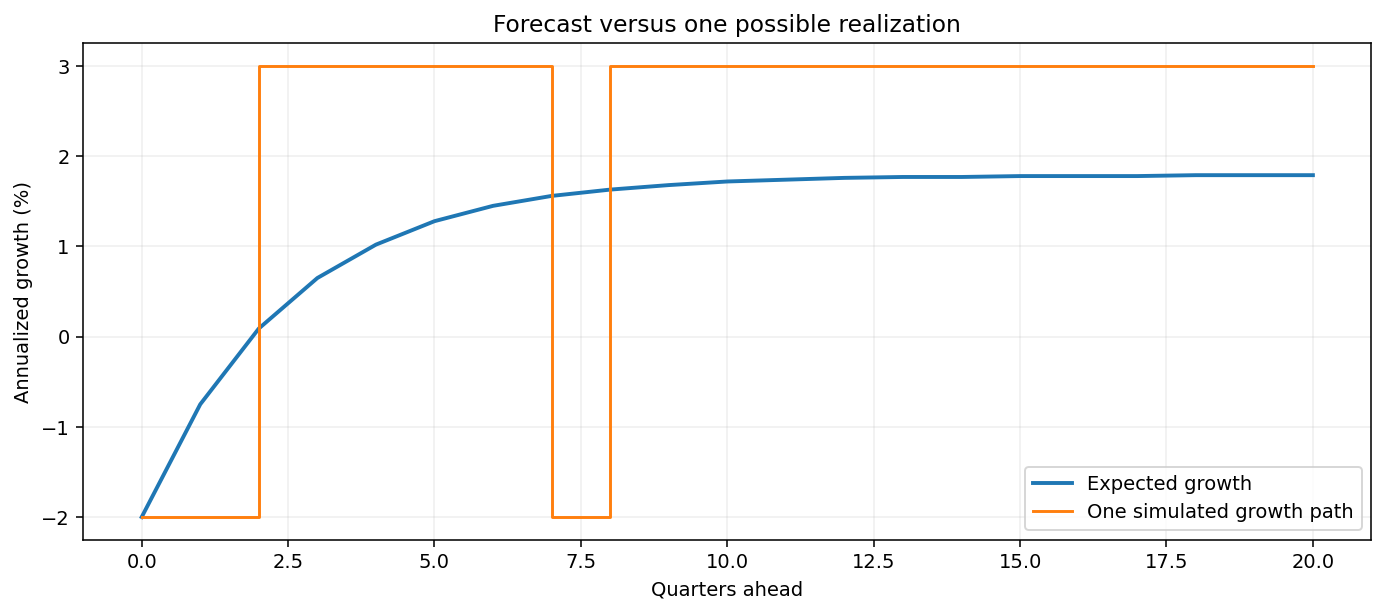

In [8]:
# Compare a conditional mean with one possible realization from the same state.
comparison_states = simulate_markov(P, T=len(horizons), s0=current_state, seed=7)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(horizons, growth_forecast, linewidth=2, label="Expected growth")
ax.step(horizons, growth[comparison_states], where="post", label="One simulated growth path")
ax.set(xlabel="Quarters ahead", ylabel="Annualized growth (%)",
       title="Forecast versus one possible realization")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


The smooth forecast averages over all possible regime paths. The simulated path takes one of the two regime-specific values at each date. A realized recession can therefore occur even at a horizon where expected growth is positive.

The gap between these lines reflects future regime uncertainty, not automatically a mistake in the forecasting model.


## 5. `discounted_markov_value`: what is the value of future fiscal revenues?

Now imagine a fiscal analyst evaluating future government revenues under the same business-cycle model. Recession brings 80 billion currency units per quarter; expansion brings 100 billion.

Let $r=[80,100]'$ and choose an illustrative **quarterly** discount factor $\beta=0.95$. Your function computes

$$
V_i=E\left[\sum_{j=0}^{\infty}\beta^j r(s_{t+j})\mid s_t=i\right].
$$

This includes today's revenue. Future revenues depend on future regimes, and their expected values are discounted. Conditioning one quarter ahead gives

$$
V=r+\beta PV,
\qquad V=(I-\beta P)^{-1}r.
$$

For a stochastic matrix and $0\leq\beta<1$, the discounted matrix series converges. This is a constant-discount expected revenue calculation; interpreting it as an asset price would require additional assumptions about risk and discounting.


In [9]:
beta = 0.95
V = discounted_markov_value(P, revenue, beta)
for name, value in zip(regime_names, V):
    print(f"Discounted revenues starting in {name.lower()}: {value:.3f} billion")
print(f"Expansion-minus-recession value: {V[1] - V[0]:.3f} billion")
print("Maximum Bellman-equation residual:", np.max(np.abs(V - revenue - beta * P @ V)))

# Verify the infinite-horizon value using a long finite discounted sum.
finite_value = np.zeros(2)
expected_revenue = revenue.copy()
for j in range(600):
    finite_value += beta**j * expected_revenue
    expected_revenue = P @ expected_revenue
assert np.allclose(V, finite_value)


Discounted revenues starting in recession: 1861.348 billion
Discounted revenues starting in expansion: 1916.369 billion
Expansion-minus-recession value: 55.021 billion
Maximum Bellman-equation residual: 0.0


The results are

$$
V\approx\begin{bmatrix}1861.348\\1916.369\end{bmatrix}
\quad\text{billion currency units}.
$$

The first number is the discounted expected sum of revenues starting in recession, not revenue in one future quarter. Starting in expansion raises this value by approximately **55.021 billion**.

Why is the difference greater than today's 20-billion revenue gap? Today's regime influences future regime probabilities, so it also changes expected future revenues. In this example,

$$
V_1-V_0=\frac{100-80}{1-0.95\times0.67}\approx55.021.
$$

If you want only revenues from **next quarter onward**, subtract today's payoff: $V-r=\beta PV$. This timing convention matters when interpreting discounted values.


## 6. `markov_loglik`: how plausible is a particular business-cycle history?

Suppose the forecasting team receives an eight-quarter history of regime labels. We can ask how much probability the model assigns to that exact sequence.

Your function calculates

$$
\ell(P; s_0,\ldots,s_{T-1})
=\log\pi^0_{s_0}+\sum_{t=0}^{T-2}\log P_{s_t,s_{t+1}},
$$

where $\pi^0$ is the assumed initial distribution. For this example, set $\pi^0=\pi$: the history is assumed to begin at a randomly selected date in a stationary economy.


In [10]:
pi0 = pi.copy()
path_clustered = np.array([1, 1, 0, 0, 0, 1, 1, 1])
path_alternating = np.array([1, 0, 1, 0, 1, 0, 1, 0])

logliks = []
for name, path in [("Clustered", path_clustered), ("Alternating", path_alternating)]:
    ll = markov_loglik(path, P, pi0)
    logliks.append(ll)
    print(f"{name}: log-likelihood = {ll:.6f}; exact-path probability = {np.exp(ll):.10f}")
print(f"Probability ratio: {np.exp(logliks[0] - logliks[1]):.1f}")


Clustered: log-likelihood = -5.015164; exact-path probability = 0.0066365455
Alternating: log-likelihood = -14.539429; exact-path probability = 0.0000004848
Probability ratio: 13687.9


The clustered path has log-likelihood approximately **−5.015164**, corresponding to probability **0.00663655** (about 0.664%). The alternating path has log-likelihood approximately **−14.539429**, corresponding to probability **0.00000048485**.

The first path is about **13,688 times** as likely as the second under this $P$. Although these histories also contain different numbers of recession quarters, the model's preference for repeated regimes makes frequent switching particularly unlikely.

These are probabilities of **specific sequences**, not probabilities that the model itself is correct. With long histories, exact-path probabilities become extremely small; log-likelihoods preserve useful numerical precision. To compare alternative transition matrices, evaluate them on the **same observed history**, with a clearly specified initial-state convention.

If the initial state is known with certainty, use a distribution with probability one on that state. For example, `pi0 = np.array([1.0, 0.0])` conditions on an initial recession. A transition assigned zero probability makes any path containing it impossible and gives log-likelihood $-\infty$.


## 7. `estimate_transition_matrix`: learn business-cycle dynamics from history

So far, we have supplied $P$. In an empirical application, we would usually estimate it from a chronologically ordered sequence of observed regime labels.

Your function counts transitions $N_{ij}$ and computes

$$
\widehat P_{ij}=\frac{N_{ij}}{\sum_j N_{ij}}.
$$

For example, if 75 of 100 recorded transitions out of recession lead to another recession quarter, the estimated recession-persistence probability is 0.75.

This is the unrestricted maximum-likelihood estimator for observed transitions, **conditional on the initial regime**, or with an initial distribution treated as fixed. If the initial distribution is constrained to be the stationary distribution of the unknown $P$, its likelihood term also depends on $P$, and this count formula need not maximize the full likelihood.

Since we do not have a country dataset here, simulate a long training history. Its length is chosen to demonstrate estimator behavior; 10,000 quarters is an artificial numerical experiment, not an available historical sample.


Observed transition counts:
[[1831  591]
 [ 590 6987]]
True transition matrix:
[[0.75 0.25]
 [0.08 0.92]]
Estimated transition matrix:
[[0.755987 0.244013]
 [0.077867 0.922133]]
Conditional log-likelihood under true P: -3418.813
Conditional log-likelihood under fitted P: -3418.344


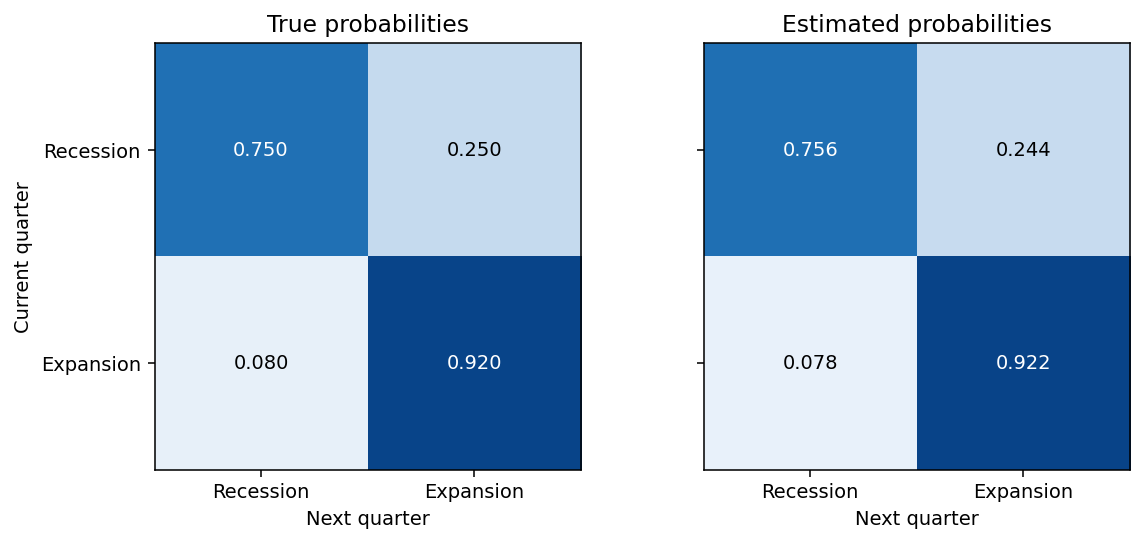

In [11]:
training_path = simulate_markov(P, T=10_000, s0=0, seed=42)
P_hat = estimate_transition_matrix(training_path, n_states=2)
counts = np.zeros((2, 2), dtype=int)
for i, j in zip(training_path[:-1], training_path[1:]):
    counts[i, j] += 1

print("Observed transition counts:", counts, sep="\n")
print("True transition matrix:", P, sep="\n")
print("Estimated transition matrix:", np.round(P_hat, 6), sep="\n")
assert np.all(counts.sum(axis=1) > 0)
assert np.allclose(P_hat.sum(axis=1), 1)

# Fix the initial state when comparing conditional likelihoods.
known_initial = np.array([1.0, 0.0])
ll_true = markov_loglik(training_path, P, known_initial)
ll_fitted = markov_loglik(training_path, P_hat, known_initial)
print(f"Conditional log-likelihood under true P: {ll_true:.3f}")
print(f"Conditional log-likelihood under fitted P: {ll_fitted:.3f}")
assert ll_fitted >= ll_true - 1e-8

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, matrix, title in zip(axes, [P, P_hat], ["True probabilities", "Estimated probabilities"]):
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks([0, 1], regime_names)
    ax.set_yticks([0, 1], regime_names)
    ax.set_xlabel("Next quarter")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center",
                    color="white" if matrix[i, j] > 0.6 else "black")
axes[0].set_ylabel("Current quarter")
fig.tight_layout()
plt.show()


With this seed, the estimate is approximately

$$
\widehat P=\begin{bmatrix}
0.755987&0.244013\\0.077867&0.922133
\end{bmatrix}.
$$

It is close to the generating matrix, but sampling variation prevents an exact match. Its conditional likelihood on the training history is at least as high as the likelihood of the true matrix because it is fitted to that particular history. Better training fit does not by itself imply better forecasting on new data.

**Important edge case in your implementation:** when a state has no recorded outgoing transitions, the function returns a row of zeros. This row is not a probability distribution, and its transition probabilities are not identified by the sample. Before using the estimate for forecasting or simulation, check that each row has observations. Additional data or an explicitly chosen smoothing procedure would be needed otherwise.

In a real empirical study, the regime labels should follow a documented classification rule. Consecutive entries must represent consecutive quarters; dropping missing quarters and treating the remaining entries as adjacent would distort the estimates. Structural changes may also make a constant $P$ inappropriate. None of these issues is solved by the transition-count estimator alone.


## Putting the seven functions into one forecasting workflow

Once the transition matrix has been estimated from an observed regime history, the other functions describe the economic implications of those estimates.

| Function | Economic question in this application |
|---|---|
| `stationary_distribution(P)` | What fraction of time is spent in recession and expansion? |
| `simulate_markov(P, T, s0, seed)` | What is one possible future sequence of business-cycle regimes? |
| `k_step_distribution(P, current_state, k)` | How likely is each regime at a specified future quarter? |
| `forecast_function(P, values, current_states, k)` | What growth or unemployment rate do we expect at that horizon? |
| `discounted_markov_value(P, payoff, beta)` | What is the discounted expected sum of future fiscal revenues? |
| `markov_loglik(path, P, pi0)` | How much probability does a candidate model assign to an observed history? |
| `estimate_transition_matrix(path, n_states)` | What transition probabilities best fit observed transitions? |

The distinction between a **regime**, a **probability**, and an **economic value** is central:

- `s_t` tells us whether the economy is in recession or expansion.
- `P` tells us how probabilities evolve between regimes.
- `growth`, `unemployment`, and `revenue` attach economic quantities to those regimes.

The functions are general because the matrix operations do not depend on these particular economic interpretations. The same code can describe productivity states, employment transitions, or income risk after changing the regime definitions, transition matrix, and associated values.

Possible extensions include a third regime for slow growth, uncertainty around estimated probabilities, and a latent-regime model in which the business-cycle state must be inferred from noisy observations. Those extensions require additional modeling choices beyond the seven functions here.
